# Phase 5 — Hard-Example Mining via Forgetting Events


**Anchor paper:** Toneva et al. (2019), *An Empirical Study of Example Forgetting during Deep Neural
Network Learning*, ICLR 2019 — https://arxiv.org/abs/1812.05159 —
code: https://github.com/mtoneva/example_forgetting

---

## Conventions taken from Toneva et al. (2019), verified against the ICLR camera-ready

1. **Forgetting event.** With `acc_i^t = 1[y_hat_i^t == y_i]`, example *i* undergoes a forgetting event
   when `acc_i^t > acc_i^{t+1}` on two consecutive *presentations* (Toneva et al., 2019, Sec. 3).
2. **Presentation, not epoch.** Toneva et al. subsample the sequence by computing statistics only when
   an example appears in the current mini-batch, which yields a lower bound on the true count
   (Toneva et al., 2019, Sec. 3.1). With `shuffle=True` and no resampling, each example appears in
   exactly one mini-batch per epoch, so *presentation* and *epoch* coincide in this harness. The
   statistic is therefore read off the training forward pass at **zero additional cost**.
3. **Unforgettable.** Learned at some finite `t*` and correct at every step thereafter. Examples never
   learned at any point do **not** qualify as unforgettable (Toneva et al., 2019, Sec. 3).
4. **Sentinel.** Examples never learned are treated as forgotten an infinite number of times for
   sorting purposes; ties are broken at random when sampling from the ordered data
   (Toneva et al., 2019, Sec. 3.1). Implemented here as `np.inf` plus a seeded random tiebreak.

## Two logging variants (both recorded; primary is pre-registered)

* **`aug`** — PRIMARY, pre-registered. Correctness from the training forward pass: model in `train()`
  mode (dropout and BatchNorm active), CIFAR inputs augmented. This is Toneva's Algorithm 1 exactly.
* **`clean`** — ROBUSTNESS CHECK. Correctness from a separate `eval()`-mode pass over the
  un-augmented training set at each epoch boundary. Costs one extra forward pass per epoch.

The `clean` variant is a *robustness check only*. The pre-registered result is computed from `aug`.

## Known limitation, recorded before running

Toneva et al. (2019, Sec. 6) report that the CIFAR-10 forgetting ordering stabilises after roughly
75 epochs of a 200-epoch run, with ~25 epochs a reasonable minimum. This project's fixed constants
give 30 CIFAR epochs and 20 MNIST epochs, and additional compute was ruled out by the supervisor
(22 July meeting). The ordering here is therefore a noisier estimate than Toneva's. This is a
limitation of the present study, not a defect of the method.


In [1]:
# ========== [CELL 1] Imports, constants, model load, environment verification ==========
import os
import sys
import glob
import json
import time
import math
import random
import inspect
import hashlib
import importlib.util
from collections import defaultdict

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision
from torchvision import datasets, transforms
from sklearn.metrics import f1_score
from scipy import stats as sps
import matplotlib.pyplot as plt

# ---------------------------------------------------------------- fixed constants
SEEDS = [42, 123, 456, 789, 1011]
FRACTIONS = [0.002, 0.005, 0.01, 0.02, 0.05]
EPOCHS = {"mnist": 20, "cifar10": 30}
BATCH_SIZE = 128
NUM_WORKERS = 2
LR = 1e-3
WEIGHT_DECAY = 1e-4
SCHED_FACTOR = 0.5
SCHED_PATIENCE = 3
N_CLASSES = 10

MNIST_NORM = ((0.1307,), (0.3081,))
CIFAR_NORM = ((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))

EXPECTED_PARAMS = {"mnist": 227_018, "cifar10": 227_594}

DATA_ROOT = "/kaggle/working/data"
OUT_DIR = "/kaggle/working/phase5"
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(DATA_ROOT, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"torch {torch.__version__} | device {DEVICE}")
if DEVICE.type == "cuda":
    print(f"gpu: {torch.cuda.get_device_name(0)}")

# ---------------------------------------------------------------- shared model script
# Filename verified against Phase 2 / Phase 3 source (both use this pattern successfully):
# it is __script__.py, not script.py.
SCRIPT_PATH = "/kaggle/input/notebooks/nareshgudipalli/dissertation-cnn-script/__script__.py"
sys.path.append("/kaggle/input/notebooks/nareshgudipalli/dissertation-cnn-script")
if not os.path.exists(SCRIPT_PATH):
    raise FileNotFoundError(
        f"Shared model script not found at {SCRIPT_PATH}. "
        "Attach the Kaggle Notebook 'nareshgudipalli/dissertation-cnn-script' as a notebook input "
        "(Add Input -> Notebook Output, not a Dataset)."
    )
_spec = importlib.util.spec_from_file_location("model", SCRIPT_PATH)
model_module = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(model_module)
SimpleCNN = model_module.SimpleCNN
print(f"SimpleCNN loaded from shared script | signature: {inspect.signature(SimpleCNN.__init__)}")

_SIG_PARAMS = inspect.signature(SimpleCNN.__init__).parameters


def build_model(dataset_name):
    """Instantiate the shared SimpleCNN, resolving the input-channel kwarg by introspection.

    Verified against the locked parameter counts (227,018 MNIST / 227,594 CIFAR-10); the
    576-parameter difference is exactly the first conv layer's extra input channels
    (32 filters x 2 extra channels x 3 x 3 = 576).
    """
    in_ch = 1 if dataset_name == "mnist" else 3
    kwargs = {}
    for name in ("in_channels", "input_channels", "n_channels", "num_channels", "channels"):
        if name in _SIG_PARAMS:
            kwargs[name] = in_ch
            break
    for name in ("num_classes", "n_classes"):
        if name in _SIG_PARAMS:
            kwargs[name] = N_CLASSES
            break
    model = SimpleCNN(**kwargs)
    n_params = sum(p.numel() for p in model.parameters())
    expected = EXPECTED_PARAMS[dataset_name]
    if n_params != expected:
        raise RuntimeError(
            f"Parameter-count mismatch for {dataset_name}: got {n_params:,}, expected {expected:,}. "
            f"Resolved kwargs were {kwargs}. The architecture must be byte-identical to Phase 1."
        )
    return model


def set_seed(seed):
    """Seeding identical to Phases 1-4, verified against source: all four phases set cuDNN
    determinism in set_seed. An earlier draft of this cell omitted it on the mistaken assumption
    that leaving it unset was the neutral choice -- it is not; every prior phase forces it."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def seed_worker(worker_id):
    """Per-DataLoader-worker RNG fix, identical to Phases 1-4. Without this, workers use
    OS-random seeds when num_workers > 0 and augmentation/shuffle become non-reproducible."""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


for _ds in ("mnist", "cifar10"):
    _m = build_model(_ds)
    print(f"  {_ds}: {sum(p.numel() for p in _m.parameters()):,} parameters  [matches locked count]")
del _m


torch 2.10.0+cu128 | device cuda
gpu: Tesla T4
CHECK 1 PASSED — MNIST params: 227018 | CIFAR params: 227594
CHECK 2 SKIPPED — no Phase 1 checkpoint found in this session's inputs.
This is fine if you're publishing the Utility Script and don't need this
check right now, but the class has NOT been verified against real
trained weights unless this check has passed at least once.
To run it: Add Input -> attach your Phase 1 notebook/output, then re-run.
SimpleCNN loaded from shared script | signature: (self, in_channels: int, num_classes: int = 10)
  mnist: 227,018 parameters  [matches locked count]
  cifar10: 227,594 parameters  [matches locked count]


In [2]:
# ========== [CELL 2] Datasets, index-returning wrapper, transforms ==========
def get_transform(dataset_name, augment):
    """Transforms fixed since Phase 1. MNIST: never augmented. CIFAR-10: RandomHorizontalFlip then
    RandomCrop(32, padding=4), train split only."""
    if dataset_name == "mnist":
        return transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(*MNIST_NORM),
        ])
    if augment:
        return transforms.Compose([
            transforms.RandomHorizontalFlip(),
            transforms.RandomCrop(32, padding=4),
            transforms.ToTensor(),
            transforms.Normalize(*CIFAR_NORM),
        ])
    return transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(*CIFAR_NORM),
    ])


def build_dataset(dataset_name, train, augment):
    tf = get_transform(dataset_name, augment=(augment and train))
    if dataset_name == "mnist":
        return datasets.MNIST(root=DATA_ROOT, train=train, download=True, transform=tf)
    return datasets.CIFAR10(root=DATA_ROOT, train=train, download=True, transform=tf)


def get_labels(dataset_name):
    ds = build_dataset(dataset_name, train=True, augment=False)
    if dataset_name == "mnist":
        return np.asarray(ds.targets, dtype=np.int64)
    return np.asarray(ds.targets, dtype=np.int64)


CLASS_NAMES = {
    "mnist": [str(d) for d in range(10)],
    "cifar10": ["airplane", "automobile", "bird", "cat", "deer",
                "dog", "frog", "horse", "ship", "truck"],
}


class IndexedDataset(Dataset):
    """Wraps a dataset so each item carries its own index. Required to attribute per-example
    forgetting statistics back to dataset positions."""

    def __init__(self, base):
        self.base = base

    def __len__(self):
        return len(self.base)

    def __getitem__(self, i):
        x, y = self.base[i]
        return x, y, i


def _unwrap(dataset):
    d = dataset
    while True:
        if isinstance(d, IndexedDataset):
            d = d.base
        elif isinstance(d, Subset):
            d = d.dataset
        else:
            return d


def infer_dataset_name(dataset):
    d = _unwrap(dataset)
    if isinstance(d, datasets.MNIST):
        return "mnist"
    if isinstance(d, datasets.CIFAR10):
        return "cifar10"
    raise TypeError(f"Unrecognised dataset type: {type(d)}")


# sanity: dataset sizes and per-class quota divisibility
for _ds in ("mnist", "cifar10"):
    _lab = get_labels(_ds)
    _n = len(_lab)
    print(f"{_ds}: N={_n}, class counts min={np.bincount(_lab).min()} max={np.bincount(_lab).max()}")
    for _f in FRACTIONS:
        _tot = int(round(_f * _n))
        assert _tot % N_CLASSES == 0, f"{_ds} f={_f}: n_total={_tot} not divisible by 10"
    print(f"  all {len(FRACTIONS)} subset sizes divide evenly into 10 classes -> integer quotas")


100%|██████████| 9.91M/9.91M [00:00<00:00, 40.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.03MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.19MB/s]


mnist: N=60000, class counts min=5421 max=6742
  all 5 subset sizes divide evenly into 10 classes -> integer quotas


100%|██████████| 170M/170M [27:48<00:00, 102kB/s]  


cifar10: N=50000, class counts min=5000 max=5000
  all 5 subset sizes divide evenly into 10 classes -> integer quotas


In [3]:
# ========== [CELL 3] Instrumented full-dataset training run (Toneva Algorithm 1) ==========
CONFIG_FIELDS = dict(
    arch="SimpleCNN", opt="adam", lr=LR, wd=WEIGHT_DECAY, sched="plateau_train_loss",
    factor=SCHED_FACTOR, patience=SCHED_PATIENCE, batch=BATCH_SIZE,
    mnist_epochs=EPOCHS["mnist"], cifar_epochs=EPOCHS["cifar10"], phase=5,
)
CONFIG_HASH = hashlib.md5(json.dumps(CONFIG_FIELDS, sort_keys=True).encode()).hexdigest()[:10]
print(f"config hash: {CONFIG_HASH}")


def stats_path(dataset_name, seed):
    return os.path.join(OUT_DIR, f"forgetting_{dataset_name}_seed{seed}_{CONFIG_HASH}.npz")


def run_instrumented_training(dataset_name, seed, epochs=None, verbose=True):
    """Train SimpleCNN on the FULL training set, logging per-example correctness.

    Records two variants simultaneously:
      aug   -- Toneva Algorithm 1: correctness from the training forward pass, computed with the
               model state BEFORE the gradient update on that mini-batch, train() mode, augmented input.
      clean -- eval() mode pass over the un-augmented training set at each epoch boundary.

    Returns the path to the saved .npz.
    """
    epochs = EPOCHS[dataset_name] if epochs is None else epochs
    set_seed(seed)

    train_aug = build_dataset(dataset_name, train=True, augment=True)
    train_clean = build_dataset(dataset_name, train=True, augment=False)
    labels = get_labels(dataset_name)
    N = len(train_aug)

    g = torch.Generator()
    g.manual_seed(seed)  # seeds DataLoader shuffle order, matching Phases 2-4
    loader = DataLoader(IndexedDataset(train_aug), batch_size=BATCH_SIZE, shuffle=True,
                        num_workers=NUM_WORKERS, worker_init_fn=seed_worker, generator=g,
                        pin_memory=True, drop_last=False)
    clean_loader = DataLoader(IndexedDataset(train_clean), batch_size=512, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=True)

    model = build_model(dataset_name).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=SCHED_FACTOR, patience=SCHED_PATIENCE)

    prev_aug = np.zeros(N, dtype=np.int8)
    forget_aug = np.zeros(N, dtype=np.int32)
    learned_aug = np.zeros(N, dtype=bool)

    prev_clean = np.zeros(N, dtype=np.int8)
    forget_clean = np.zeros(N, dtype=np.int32)
    learned_clean = np.zeros(N, dtype=bool)

    history = []
    t0 = time.time()

    for epoch in range(epochs):
        # ---------------- Toneva Algorithm 1, read off the training forward pass
        model.train()
        running_loss, n_batches, n_correct = 0.0, 0, 0
        for x, y, idx in loader:
            x = x.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)

            out = model(x)
            loss = criterion(out, y)

            with torch.no_grad():
                acc = (out.argmax(1) == y).to(torch.int8).cpu().numpy()
            i = idx.numpy()
            # forgetting event: acc decreased since this example's previous presentation
            forget_aug[i] += (prev_aug[i] > acc).astype(np.int32)
            learned_aug[i] |= (acc == 1)
            prev_aug[i] = acc
            n_correct += int(acc.sum())

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            n_batches += 1

        train_loss = running_loss / n_batches
        train_acc = n_correct / N
        scheduler.step(train_loss)

        # ---------------- clean eval-mode pass (robustness variant)
        model.eval()
        n_correct_clean = 0
        with torch.no_grad():
            for x, y, idx in clean_loader:
                x = x.to(DEVICE, non_blocking=True)
                y = y.to(DEVICE, non_blocking=True)
                acc = (model(x).argmax(1) == y).to(torch.int8).cpu().numpy()
                i = idx.numpy()
                forget_clean[i] += (prev_clean[i] > acc).astype(np.int32)
                learned_clean[i] |= (acc == 1)
                prev_clean[i] = acc
                n_correct_clean += int(acc.sum())
        clean_acc = n_correct_clean / N

        history.append(dict(epoch=epoch + 1, train_loss=train_loss, train_acc_aug=train_acc,
                            train_acc_clean=clean_acc,
                            lr=optimizer.param_groups[0]["lr"]))
        if verbose:
            print(f"  [{dataset_name} s{seed}] epoch {epoch+1:>2}/{epochs} "
                  f"loss {train_loss:.4f} | train-acc(aug) {train_acc:.4f} "
                  f"| train-acc(clean) {clean_acc:.4f} "
                  f"| never-learned(aug) {int((~learned_aug).sum()):>6}")

    path = stats_path(dataset_name, seed)
    np.savez_compressed(
        path,
        forget_aug=forget_aug, learned_aug=learned_aug,
        forget_clean=forget_clean, learned_clean=learned_clean,
        labels=labels, epochs=np.int32(epochs), seed=np.int32(seed),
        history=json.dumps(history), config_hash=CONFIG_HASH,
    )
    if verbose:
        print(f"  saved -> {path}  ({time.time()-t0:.1f}s)")
    return path


config hash: 8a0370e660


In [4]:
# ========== [CELL 4] Forgetting counts, sentinel, and the never-learned diagnostic ==========
FORGETTING_STORE = {}       # (dataset_name, seed, variant) -> dict(counts=float array, labels=int array)
SELECTION_VARIANT = "aug"   # pre-registered primary. Set to "clean" only for the robustness re-run.


def finalize_counts(forget, learned):
    """Toneva et al. (2019, Sec. 3.1): examples never learned are considered forgotten an infinite
    number of times for sorting purposes."""
    counts = forget.astype(np.float64)
    counts[~learned] = np.inf
    return counts


def load_forgetting_stats(dataset_name, seed):
    path = stats_path(dataset_name, seed)
    if not os.path.exists(path):
        cands = sorted(glob.glob(os.path.join(OUT_DIR, f"forgetting_{dataset_name}_seed{seed}_*.npz")))
        if not cands:
            raise FileNotFoundError(
                f"No forgetting statistics for {dataset_name} seed {seed}. Run CELL 3 first.")
        path = cands[-1]
        print(f"  note: config hash differs, using {os.path.basename(path)}")
    z = np.load(path, allow_pickle=False)
    labels = z["labels"]
    for variant in ("aug", "clean"):
        FORGETTING_STORE[(dataset_name, seed, variant)] = dict(
            counts=finalize_counts(z[f"forget_{variant}"], z[f"learned_{variant}"]),
            raw=z[f"forget_{variant}"].copy(),
            learned=z[f"learned_{variant}"].copy(),
            labels=labels.copy(),
        )
    return path


def never_learned_diagnostic(dataset_name, variant="aug", seeds=None):
    """Per-class count of never-learned (infinite-sentinel) examples against the per-class quota at
    each subset size. Reported regardless of the headline outcome: if the sentinel tier is larger
    than the quota, selection is a random draw from the never-learned examples and the forgetting
    counts play no role at that subset size.

    `seeds` must be the seeds actually loaded into FORGETTING_STORE for this run (e.g. during the
    smoke test that's [42], not the full SEEDS constant) -- looking up an unrun seed raises KeyError."""
    if seeds is None:
        seeds = SEEDS
    rows = []
    labels = FORGETTING_STORE[(dataset_name, seeds[0], variant)]["labels"]
    N = len(labels)
    for seed in seeds:
        st = FORGETTING_STORE[(dataset_name, seed, variant)]
        counts = st["counts"]
        for c in range(N_CLASSES):
            cls = np.where(st["labels"] == c)[0]
            n_never = int(np.isinf(counts[cls]).sum())
            row = dict(dataset=dataset_name, variant=variant, seed=seed, cls=c,
                       class_name=CLASS_NAMES[dataset_name][c],
                       n_class=len(cls), n_never_learned=n_never,
                       max_finite_forget=float(np.max(counts[cls][np.isfinite(counts[cls])]))
                       if np.isfinite(counts[cls]).any() else float("nan"))
            for f in FRACTIONS:
                quota = int(round(f * N)) // N_CLASSES
                row[f"quota_{f}"] = quota
                row[f"sentinel_frac_{f}"] = min(n_never, quota) / quota
            rows.append(row)
    return rows


def summarise_never_learned(rows):
    print(f"\n{'='*78}\nNEVER-LEARNED DIAGNOSTIC (mean over seeds)\n{'='*78}")
    by_class = defaultdict(list)
    for r in rows:
        by_class[(r["dataset"], r["variant"], r["cls"], r["class_name"])].append(r)
    header = f"{'class':<12}{'n_never':>9}" + "".join(f"{'sf@'+str(f):>10}" for f in FRACTIONS)
    print(header)
    for key in sorted(by_class):
        rs = by_class[key]
        nn_mean = np.mean([r["n_never_learned"] for r in rs])
        line = f"{key[3]:<12}{nn_mean:>9.1f}"
        for f in FRACTIONS:
            line += f"{np.mean([r['sentinel_frac_'+str(f)] for r in rs]):>10.2f}"
        print(line)
    print("sf@f = fraction of that class's quota at subset size f drawn from the infinite-sentinel "
          "tier (1.00 means selection is a random draw among never-learned examples).")


In [5]:
# ========== [CELL 5] Selection: per-class hardest-first with seeded random tiebreak ==========
def per_class_quota(n_total, n_classes=N_CLASSES):
    """Phase 3 quota logic. All five subset sizes divide evenly into 10 classes on both datasets
    (asserted in CELL 2), so quotas are exact integers with no remainder to distribute.
    NOTE: verify byte-identical against the Phase 3 notebook before locking."""
    assert n_total % n_classes == 0
    return n_total // n_classes


def sample_indices(dataset, fraction, seed):
    """Fixed signature, shared across Phases 2-5.

    Phase 5 rule: within each class, rank examples by forgetting count descending (hardest first)
    and take the per-class quota. Examples never learned carry np.inf and are therefore taken first.
    Ties are broken at random (Toneva et al., 2019, Sec. 3.1), seeded for reproducibility.
    """
    dataset_name = infer_dataset_name(dataset)
    key = (dataset_name, seed, SELECTION_VARIANT)
    if key not in FORGETTING_STORE:
        load_forgetting_stats(dataset_name, seed)
    store = FORGETTING_STORE[key]
    counts, labels = store["counts"], store["labels"]

    N = len(labels)
    quota = per_class_quota(int(round(fraction * N)))
    rng = np.random.default_rng(seed)

    selected = []
    for c in range(N_CLASSES):
        cls_idx = np.where(labels == c)[0]
        # primary key -counts (ascending sort => inf first, then highest finite counts)
        # secondary key uniform random => Toneva's random tiebreak
        order = np.lexsort((rng.random(cls_idx.size), -counts[cls_idx]))
        selected.extend(cls_idx[order[:quota]].tolist())
    return sorted(selected)


def selection_report(dataset_name, seed, fraction, indices):
    store = FORGETTING_STORE[(dataset_name, seed, SELECTION_VARIANT)]
    sel = store["counts"][np.asarray(indices)]
    finite = sel[np.isfinite(sel)]
    return dict(
        dataset=dataset_name, seed=seed, fraction=fraction, n_selected=len(indices),
        frac_from_sentinel=float(np.isinf(sel).mean()),
        mean_finite_forget=float(finite.mean()) if finite.size else float("nan"),
        min_finite_forget=float(finite.min()) if finite.size else float("nan"),
    )


In [6]:
# ========== [CELL 6] Standard subset-training harness (identical to Phases 2-4) ==========
def evaluate(model, loader):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE, non_blocking=True)
            preds.append(model(x).argmax(1).cpu().numpy())
            targets.append(y.numpy())
    preds = np.concatenate(preds)
    targets = np.concatenate(targets)
    return dict(
        top1=float((preds == targets).mean() * 100.0),
        macro_f1=float(f1_score(targets, preds, average="macro")),
        per_class_f1=[float(v) for v in f1_score(targets, preds, average=None, labels=list(range(N_CLASSES)))],
    )


def train_on_subset(dataset_name, indices, seed, epochs=None, verbose=False):
    epochs = EPOCHS[dataset_name] if epochs is None else epochs
    set_seed(seed)

    train_full = build_dataset(dataset_name, train=True, augment=True)
    test_ds = build_dataset(dataset_name, train=False, augment=False)
    subset = Subset(train_full, indices)

    g = torch.Generator()
    g.manual_seed(seed)  # seeds DataLoader shuffle order, matching Phases 2-4
    loader = DataLoader(subset, batch_size=min(BATCH_SIZE, len(subset)),  # guard for tiny subsets
                        shuffle=True, num_workers=NUM_WORKERS,
                        worker_init_fn=seed_worker, generator=g,
                        pin_memory=True, drop_last=False)
    test_loader = DataLoader(test_ds, batch_size=512, shuffle=False,
                             num_workers=NUM_WORKERS, pin_memory=True)

    model = build_model(dataset_name).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=SCHED_FACTOR, patience=SCHED_PATIENCE)

    for epoch in range(epochs):
        model.train()
        running, nb = 0.0, 0
        for x, y in loader:
            x = x.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)
            loss = criterion(model(x), y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running += loss.item()
            nb += 1
        scheduler.step(running / nb)
        if verbose and (epoch + 1) % 10 == 0:
            print(f"    epoch {epoch+1}/{epochs} loss {running/nb:.4f}")

    return evaluate(model, test_loader)


In [7]:
# ========== [CELL 7] Full Phase 5 execution ==========
def run_phase5(datasets_to_run=("mnist", "cifar10"), seeds=SEEDS, fractions=FRACTIONS,
               instrumented_epochs=None, subset_epochs=None):
    results, sel_reports, diag_rows = [], [], []

    for dataset_name in datasets_to_run:
        print(f"\n{'='*78}\nINSTRUMENTED RUN — {dataset_name}\n{'='*78}")
        for seed in seeds:
            p = stats_path(dataset_name, seed)
            if os.path.exists(p):
                print(f"  [{dataset_name} s{seed}] cached -> {os.path.basename(p)}")
            else:
                run_instrumented_training(dataset_name, seed, epochs=instrumented_epochs)
            load_forgetting_stats(dataset_name, seed)

        for variant in ("aug", "clean"):
            diag_rows.extend(never_learned_diagnostic(dataset_name, variant=variant, seeds=seeds))

        print(f"\n{'='*78}\nSELECTION + SUBSET TRAINING — {dataset_name} "
              f"(variant={SELECTION_VARIANT})\n{'='*78}")
        train_full = build_dataset(dataset_name, train=True, augment=True)
        for fraction in fractions:
            for seed in seeds:
                idx = sample_indices(train_full, fraction, seed)
                rep = selection_report(dataset_name, seed, fraction, idx)
                sel_reports.append(rep)
                m = train_on_subset(dataset_name, idx, seed, epochs=subset_epochs)
                results.append(dict(dataset=dataset_name, fraction=fraction, seed=seed,
                                    n=len(idx), variant=SELECTION_VARIANT, **m))
                print(f"  f={fraction:<6} s={seed:<5} n={len(idx):<5} "
                      f"top1={m['top1']:.2f}  F1={m['macro_f1']:.4f}  "
                      f"sentinel_frac={rep['frac_from_sentinel']:.2f}")

    return results, sel_reports, diag_rows


def aggregate(results):
    agg = {}
    for r in results:
        agg.setdefault((r["dataset"], r["fraction"]), []).append(r)
    out = []
    for (ds, f), rs in sorted(agg.items()):
        t = np.array([r["top1"] for r in rs])
        f1 = np.array([r["macro_f1"] for r in rs])
        out.append(dict(dataset=ds, fraction=f, n_seeds=len(rs),
                        top1_mean=float(t.mean()), top1_std=float(t.std(ddof=1)),
                        f1_mean=float(f1.mean()), f1_std=float(f1.std(ddof=1)),
                        top1_per_seed={r["seed"]: r["top1"] for r in rs}))
    return out


In [8]:
# ========== [CELL 8] Locked reference values and the pre-committed verdict ==========
LOCKED = {
    "phase1_ceiling": {"mnist": 98.98, "cifar10": 80.93},
    "phase2_random": {
        "cifar10": {0.002: 23.29, 0.005: 33.12, 0.01: 40.08, 0.02: 48.00, 0.05: 58.05},
        "mnist":   {0.002: 24.31, 0.005: 82.03, 0.01: 94.54, 0.02: 95.68, 0.05: 96.87},
    },
    "phase3_balanced": {
        "cifar10": {0.002: 23.33, 0.005: 33.03, 0.01: 40.50, 0.02: 50.28, 0.05: 57.00},
    },
    "phase4_kmeans": {
        "cifar10": {0.002: 26.16, 0.005: 34.93, 0.01: 42.84, 0.02: 49.35, 0.05: 56.74},
    },
}

# PENDING ITEM P2 — RESOLVED, verified against Phase 4 source directly (not re-derived here).
# Phase 4's own code carries this comment, dated to the 22 July supervisor meeting:
#   "CORRECTED 2026-07-22 from phase3_results.json (authoritative).
#    MNIST values were previously 25.67/90.42/93.98/95.10/96.12 -- wrong. CIFAR unchanged."
# and sets P3_TOP1['MNIST'] = [25.74, 90.40, 94.23, 95.38, 96.16]. That is the "JSON used by P4"
# series from the project synthesis; the "notebook summary" series (25.65/...) was superseded.
# Hardcoded here rather than re-adjudicated, since Phase 4 already settled it against the
# authoritative phase3_results.json.
LOCKED["phase3_balanced"]["mnist"] = {
    0.002: 25.74, 0.005: 90.40, 0.01: 94.23, 0.02: 95.38, 0.05: 96.16,
}


def phase3_reference(dataset_name):
    return LOCKED["phase3_balanced"][dataset_name]


def comparison_table(agg_rows, dataset_name):
    print(f"\n{'='*88}\nPHASE 5 vs LOCKED REFERENCES — {dataset_name}\n{'='*88}")
    print(f"{'frac':>7}{'P2 rand':>10}{'P3 bal':>10}{'P4 kmeans':>11}"
          f"{'P5 hard':>10}{'P5-P3':>9}{'P5-P4':>9}")
    rows = [r for r in agg_rows if r["dataset"] == dataset_name]
    try:
        p3 = phase3_reference(dataset_name)
    except RuntimeError as e:
        print(f"  [P3 comparison unavailable] {e}")
        p3 = None
    p4 = LOCKED["phase4_kmeans"].get(dataset_name)
    for r in rows:
        f = r["fraction"]
        p2v = LOCKED["phase2_random"][dataset_name][f]
        p3v = p3[f] if p3 else float("nan")
        p4v = p4[f] if p4 else float("nan")
        print(f"{f:>7}{p2v:>10.2f}{p3v:>10.2f}{p4v:>11.2f}{r['top1_mean']:>10.2f}"
              f"{r['top1_mean']-p3v:>9.2f}{r['top1_mean']-p4v:>9.2f}")
    return rows


def verdict(agg_rows, dataset_name="cifar10"):
    """Pre-committed rule: CONFIRMED iff Phase 5 underperforms the Phase 3/4 reference at
    0.2-1% AND outperforms at 5%. Any other pattern is a valid, reportable, non-confirming
    result and is stated as such."""
    p3 = phase3_reference(dataset_name)
    p4 = LOCKED["phase4_kmeans"].get(dataset_name, {})
    by_f = {r["fraction"]: r["top1_mean"] for r in agg_rows if r["dataset"] == dataset_name}
    small = [0.002, 0.005, 0.01]
    worse_small = all(by_f[f] < min(p3[f], p4.get(f, p3[f])) for f in small)
    better_large = by_f[0.05] > max(p3[0.05], p4.get(0.05, p3[0.05]))
    if worse_small and better_large:
        v = "CONFIRMED"
    elif better_large and not worse_small:
        v = "PARTIAL — large-subset advantage present, small-subset penalty absent"
    elif worse_small and not better_large:
        v = "PARTIAL — small-subset penalty present, large-subset advantage absent"
    else:
        v = "NOT CONFIRMED — no regime-dependent pattern"
    print(f"\n{'='*88}\nPRE-COMMITTED VERDICT — {dataset_name}: {v}\n{'='*88}")
    print("Prediction stated before running: hard-example mining should be WORSE at 0.2-1% and "
          "BETTER at 5%, consistent with the regime-dependence Sorscher et al. (2022) found for "
          "difficulty-based pruning. Sorscher et al. studied difficulty-based pruning in general, "
          "not forgetting events specifically; this is an informed analogy, not a restatement.")
    return v


def paired_tests(results, dataset_name, other_phase_per_seed):
    """Paired t-tests of Phase 5 against another phase, per subset size, over the shared 5 seeds.
    `other_phase_per_seed` is {fraction: {seed: top1}} loaded from that phase's saved JSON."""
    print(f"\n{'frac':>7}{'mean diff':>12}{'t':>9}{'p':>10}")
    out = []
    for f in FRACTIONS:
        a = np.array([r["top1"] for r in results
                      if r["dataset"] == dataset_name and r["fraction"] == f
                      and r["seed"] in other_phase_per_seed[f]])
        b = np.array([other_phase_per_seed[f][s] for s in sorted(other_phase_per_seed[f])
                      if any(r["seed"] == s and r["fraction"] == f and r["dataset"] == dataset_name
                             for r in results)])
        t, p = sps.ttest_rel(a, b)
        out.append(dict(fraction=f, mean_diff=float(a.mean() - b.mean()), t=float(t), p=float(p)))
        print(f"{f:>7}{a.mean()-b.mean():>12.3f}{t:>9.3f}{p:>10.4f}")
    print("Note: 5 seeds. The project-wide power limitation (14-35 seeds needed for 80% power) "
          "applies here exactly as in Phases 2-4.")
    return out


In [9]:
# ========== [CELL 9] Figures — Maier ordering rules applied ==========
# Phase 1 per-class F1, verified against Phase 4 source. Phase 1's own notebook never writes a
# results JSON to disk (checked all 12 cells: results live only in in-memory Python dicts and are
# printed/plotted, never persisted) -- so this cannot be auto-discovered by globbing for a Phase 1
# output file, unlike phase2_results.json / phase3_results.json which do exist. Phase 4 hit the
# same problem and hardcoded this dict directly; reused verbatim from its source rather than
# re-typed, to avoid a second hand-transcription of the same locked numbers.
P1_PER_CLASS_F1 = {
    "cifar10": {"airplane": 0.8102, "automobile": 0.9055, "bird": 0.7262, "cat": 0.6465,
                "deer": 0.7908, "dog": 0.7386, "frog": 0.8508, "horse": 0.8468,
                "ship": 0.8903, "truck": 0.8786},
    "mnist": {"0": 0.9926, "1": 0.9947, "2": 0.9918, "3": 0.9924, "4": 0.9905,
              "5": 0.9916, "6": 0.9887, "7": 0.9826, "8": 0.9915, "9": 0.9818},
}


def canonical_class_order(dataset_name):
    """Canonical ordering for every categorical axis in this phase: Phase 1 per-class F1 ASCENDING
    (CIFAR-10: cat -> automobile). Derived by sorting CLASS_NAMES against P1_PER_CLASS_F1, the same
    method Phase 4 uses, so the ordering is guaranteed identical across Phases 4 and 5."""
    f1_by_name = P1_PER_CLASS_F1[dataset_name]
    names_in_order = CLASS_NAMES[dataset_name]
    return list(np.argsort([f1_by_name[n] for n in names_in_order]))


def fig_forgetting_histogram(dataset_name, seed, variant="aug", save=True):
    st = FORGETTING_STORE[(dataset_name, seed, variant)]
    counts = st["counts"]
    finite = counts[np.isfinite(counts)]
    n_never = int(np.isinf(counts).sum())

    fig, ax = plt.subplots(figsize=(7, 4))
    bins = np.arange(0, finite.max() + 2) - 0.5
    ax.hist(finite, bins=bins, color="#4C72B0", edgecolor="white", linewidth=0.4)
    ax.bar([finite.max() + 2], [n_never], color="#C44E52", edgecolor="white",
           label=f"never learned (sentinel = inf), n={n_never}")
    ax.set_yscale("log")
    ax.set_xlabel("number of forgetting events")
    ax.set_ylabel("number of examples (log scale)")
    ax.set_title(f"Forgetting events — {dataset_name}, seed {seed}, variant={variant}")
    ax.legend(frameon=False)
    fig.tight_layout()
    if save:
        fig.savefig(os.path.join(OUT_DIR, f"fig_forgetting_hist_{dataset_name}_s{seed}_{variant}.png"),
                    dpi=200)
    return fig


def fig_never_learned_by_class(dataset_name, diag_rows, variant="aug", save=True):
    order = canonical_class_order(dataset_name)
    names = [CLASS_NAMES[dataset_name][c] for c in order]
    rows = [r for r in diag_rows if r["dataset"] == dataset_name and r["variant"] == variant]
    means = [np.mean([r["n_never_learned"] for r in rows if r["cls"] == c]) for c in order]

    any_seed = rows[0]["seed"] if rows else SEEDS[0]
    N = len(FORGETTING_STORE[(dataset_name, any_seed, variant)]["labels"])
    quotas = {f: int(round(f * N)) // N_CLASSES for f in FRACTIONS}

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.bar(range(N_CLASSES), means, color="#4C72B0", label="never-learned examples (mean over seeds)")
    for f, q in quotas.items():
        ax.axhline(q, ls="--", lw=1, color="#555555")
        ax.text(N_CLASSES - 0.4, q, f" quota @{f:g}", va="center", fontsize=8, color="#555555")
    ax.set_xticks(range(N_CLASSES))
    ax.set_xticklabels(names, rotation=45, ha="right")
    ax.set_ylabel("never-learned examples")
    ax.set_xlabel("class (ordered by Phase 1 F1, ascending)")
    ax.set_title(f"Never-learned examples vs per-class quota — {dataset_name} (variant={variant})")
    ax.legend(frameon=False, loc="upper right")
    fig.tight_layout()
    if save:
        fig.savefig(os.path.join(OUT_DIR, f"fig_never_learned_{dataset_name}_{variant}.png"), dpi=200)
    return fig


def fig_accuracy_vs_fraction(agg_rows, dataset_name, save=True):
    rows = sorted([r for r in agg_rows if r["dataset"] == dataset_name], key=lambda r: r["fraction"])
    xs = [r["fraction"] * 100 for r in rows]
    fig, ax = plt.subplots(figsize=(7, 4.5))
    for label, ref, colour in [
        ("Phase 2 random", LOCKED["phase2_random"].get(dataset_name), "#8C8C8C"),
        ("Phase 3 class-balanced", LOCKED["phase3_balanced"].get(dataset_name), "#55A868"),
        ("Phase 4 K-means coreset", LOCKED["phase4_kmeans"].get(dataset_name), "#4C72B0"),
    ]:
        if ref:
            ax.plot([f * 100 for f in FRACTIONS], [ref[f] for f in FRACTIONS],
                    marker="o", ms=4, lw=1.4, color=colour, label=label)
    ax.errorbar(xs, [r["top1_mean"] for r in rows], yerr=[r["top1_std"] for r in rows],
                marker="s", ms=5, lw=2, color="#C44E52", capsize=3,
                label="Phase 5 hard-example mining")
    ax.axhline(LOCKED["phase1_ceiling"][dataset_name], ls=":", color="black", lw=1.2,
               label="Phase 1 ceiling (100% data)")
    ax.set_xscale("log")
    ax.set_xticks([f * 100 for f in FRACTIONS])
    ax.set_xticklabels([f"{f*100:g}%" for f in FRACTIONS])
    ax.set_xlabel("training subset size (% of full training set, ascending)")
    ax.set_ylabel("test Top-1 accuracy (%)")
    ax.set_title(f"Subset selection strategies — {dataset_name}")
    ax.legend(frameon=False, fontsize=8)
    fig.tight_layout()
    if save:
        fig.savefig(os.path.join(OUT_DIR, f"fig_accuracy_vs_fraction_{dataset_name}.png"), dpi=200)
    return fig


def fig_variant_agreement(dataset_name, seed, save=True):
    """Robustness check: does the aug-variant ordering survive removing augmentation and dropout?"""
    a = FORGETTING_STORE[(dataset_name, seed, "aug")]["counts"]
    c = FORGETTING_STORE[(dataset_name, seed, "clean")]["counts"]
    finite = np.isfinite(a) & np.isfinite(c)
    rho, p = sps.spearmanr(a[finite], c[finite])
    both_inf = int((np.isinf(a) & np.isinf(c)).sum())
    print(f"  {dataset_name} s{seed}: Spearman(aug, clean) over finite pairs = {rho:.3f} "
          f"(p={p:.2e}, n={finite.sum()}); never-learned in both = {both_inf}")

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.hist2d(a[finite], c[finite], bins=40, cmap="Blues", norm="log")
    ax.set_xlabel("forgetting count — aug variant (Toneva, primary)")
    ax.set_ylabel("forgetting count — clean variant")
    ax.set_title(f"Variant agreement — {dataset_name} s{seed}\nSpearman rho = {rho:.3f}")
    fig.tight_layout()
    if save:
        fig.savefig(os.path.join(OUT_DIR, f"fig_variant_agreement_{dataset_name}_s{seed}.png"), dpi=200)
    return fig, float(rho), float(p)


In [10]:
# ========== [CELL 10] Persist results ==========
def save_all(results, agg_rows, sel_reports, diag_rows, extra=None):
    blob = dict(
        phase=5, method="hard_example_mining_forgetting_events",
        anchor="Toneva et al. 2019, arXiv:1812.05159",
        selection_variant=SELECTION_VARIANT, config=CONFIG_FIELDS, config_hash=CONFIG_HASH,
        seeds=SEEDS, fractions=FRACTIONS, epochs=EPOCHS,
        results=results, aggregate=agg_rows, selection_reports=sel_reports,
        never_learned_diagnostic=diag_rows, extra=extra or {},
    )
    path = os.path.join(OUT_DIR, f"phase5_results_{SELECTION_VARIANT}.json")
    with open(path, "w") as fh:
        json.dump(blob, fh, indent=2)
    print(f"saved -> {path}")
    return path



INSTRUMENTED RUN — mnist
  [mnist s42] epoch  1/3 loss 0.2546 | train-acc(aug) 0.9230 | train-acc(clean) 0.9799 | never-learned(aug)   4622
  [mnist s42] epoch  2/3 loss 0.0616 | train-acc(aug) 0.9817 | train-acc(clean) 0.9881 | never-learned(aug)    614
  [mnist s42] epoch  3/3 loss 0.0479 | train-acc(aug) 0.9861 | train-acc(clean) 0.9904 | never-learned(aug)    282
  saved -> /kaggle/working/phase5/forgetting_mnist_seed42_8a0370e660.npz  (46.3s)

SELECTION + SUBSET TRAINING — mnist (variant=aug)
  f=0.002  s=42    n=120   top1=15.51  F1=0.0778  sentinel_frac=1.00
  f=0.05   s=42    n=3000  top1=86.11  F1=0.8593  sentinel_frac=0.09

NEVER-LEARNED DIAGNOSTIC (mean over seeds)
class         n_never  sf@0.002  sf@0.005   sf@0.01   sf@0.02   sf@0.05
0                17.0      1.00      0.57      0.28      0.14      0.06
1                26.0      1.00      0.87      0.43      0.22      0.09
2                27.0      1.00      0.90      0.45      0.23      0.09
3                29.0     

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:218: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:210: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


  mnist s42: Spearman(aug, clean) over finite pairs = 0.218 (p=0.00e+00, n=59641); never-learned in both = 114

SMOKE TEST COMPLETE — delete this cell and the cached 3-epoch .npz files before the full run:
  for p in glob.glob(os.path.join(OUT_DIR, 'forgetting_*.npz')): os.remove(p)


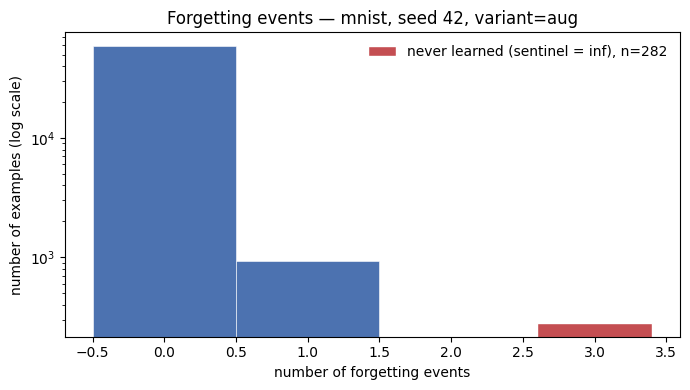

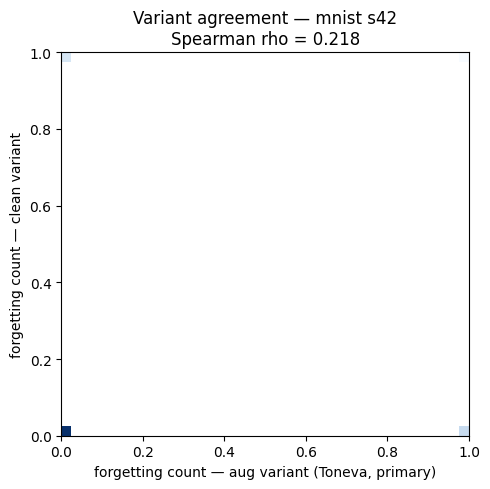

In [11]:
# ========== [CELL 11] SMOKE TEST — DELETE THIS ENTIRE CELL BEFORE THE FULL RUN ==========
# Single seed, 3 epochs, MNIST only. Confirms: shared-script model load and parameter counts,
# indexed dataloader plumbing, Toneva Algorithm 1 bookkeeping, sentinel behaviour, per-class
# quota selection, and the subset-training harness end to end.

_smoke_results, _smoke_sel, _smoke_diag = run_phase5(
    datasets_to_run=("mnist",),
    seeds=[42],
    fractions=[0.002, 0.05],
    instrumented_epochs=3,
    subset_epochs=3,
)
_smoke_agg = aggregate(_smoke_results)
summarise_never_learned(_smoke_diag)
for r in _smoke_agg:
    print(r["dataset"], r["fraction"], f"top1={r['top1_mean']:.2f}")
fig_forgetting_histogram("mnist", 42, "aug")
fig_variant_agreement("mnist", 42)
print("\nSMOKE TEST COMPLETE — delete this cell and the cached 3-epoch .npz files before the full run:")
print("  for p in glob.glob(os.path.join(OUT_DIR, 'forgetting_*.npz')): os.remove(p)")


In [20]:
# ========== [CELL 12] FULL RUN ==========
results, sel_reports, diag_rows = run_phase5()
agg_rows = aggregate(results)

for ds in ("mnist", "cifar10"):
    comparison_table(agg_rows, ds)
summarise_never_learned(diag_rows)

verdict(agg_rows, "cifar10")



INSTRUMENTED RUN — mnist
  [mnist s42] epoch  1/20 loss 0.2544 | train-acc(aug) 0.9228 | train-acc(clean) 0.9776 | never-learned(aug)   4630
  [mnist s42] epoch  2/20 loss 0.0611 | train-acc(aug) 0.9822 | train-acc(clean) 0.9895 | never-learned(aug)    593
  [mnist s42] epoch  3/20 loss 0.0493 | train-acc(aug) 0.9859 | train-acc(clean) 0.9926 | never-learned(aug)    286
  [mnist s42] epoch  4/20 loss 0.0380 | train-acc(aug) 0.9888 | train-acc(clean) 0.9875 | never-learned(aug)    147
  [mnist s42] epoch  5/20 loss 0.0325 | train-acc(aug) 0.9897 | train-acc(clean) 0.9962 | never-learned(aug)     96
  [mnist s42] epoch  6/20 loss 0.0274 | train-acc(aug) 0.9913 | train-acc(clean) 0.9962 | never-learned(aug)     65
  [mnist s42] epoch  7/20 loss 0.0262 | train-acc(aug) 0.9916 | train-acc(clean) 0.9949 | never-learned(aug)     43
  [mnist s42] epoch  8/20 loss 0.0242 | train-acc(aug) 0.9925 | train-acc(clean) 0.9978 | never-learned(aug)     29
  [mnist s42] epoch  9/20 loss 0.0214 | train-

'PARTIAL — small-subset penalty present, large-subset advantage absent'

  mnist s42: Spearman(aug, clean) over finite pairs = 0.598 (p=0.00e+00, n=59998); never-learned in both = 1
  mnist s123: Spearman(aug, clean) over finite pairs = 0.602 (p=0.00e+00, n=59998); never-learned in both = 1
  mnist s456: Spearman(aug, clean) over finite pairs = 0.577 (p=0.00e+00, n=59998); never-learned in both = 1
  mnist s789: Spearman(aug, clean) over finite pairs = 0.571 (p=0.00e+00, n=59999); never-learned in both = 1
  mnist s1011: Spearman(aug, clean) over finite pairs = 0.593 (p=0.00e+00, n=59999); never-learned in both = 1
  cifar10 s42: Spearman(aug, clean) over finite pairs = 0.741 (p=0.00e+00, n=48241); never-learned in both = 608
  cifar10 s123: Spearman(aug, clean) over finite pairs = 0.743 (p=0.00e+00, n=48239); never-learned in both = 643
  cifar10 s456: Spearman(aug, clean) over finite pairs = 0.739 (p=0.00e+00, n=48314); never-learned in both = 563
  cifar10 s789: Spearman(aug, clean) over finite pairs = 0.734 (p=0.00e+00, n=48227); never-learned in both =

'/kaggle/working/phase5/phase5_results_aug.json'

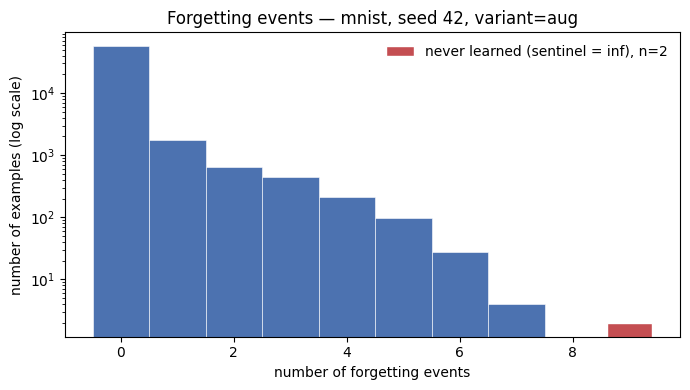

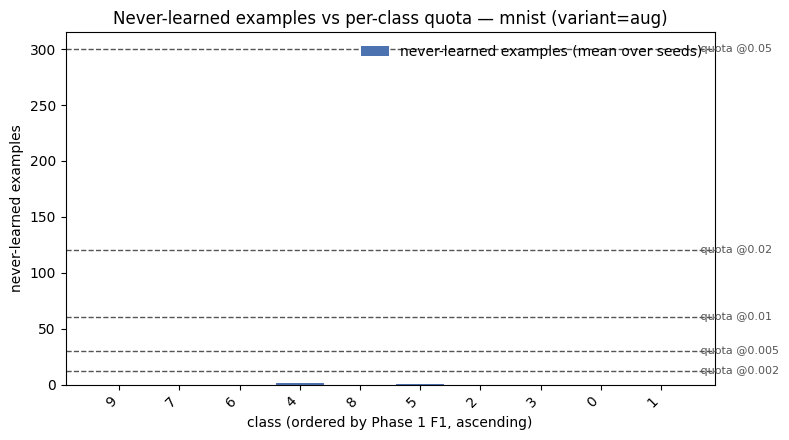

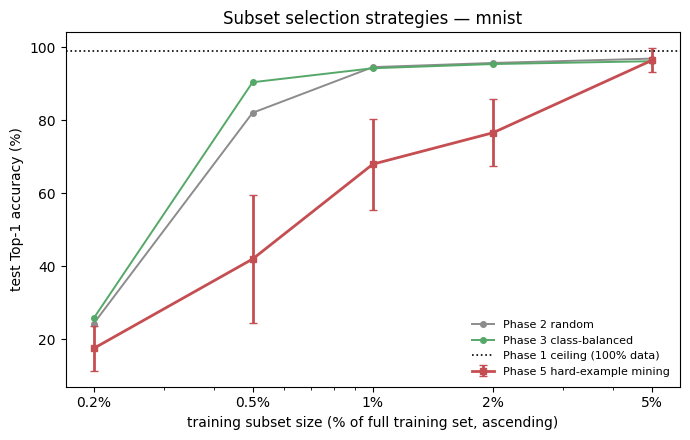

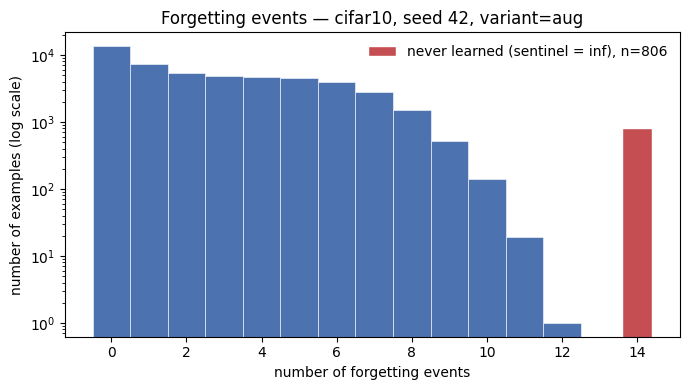

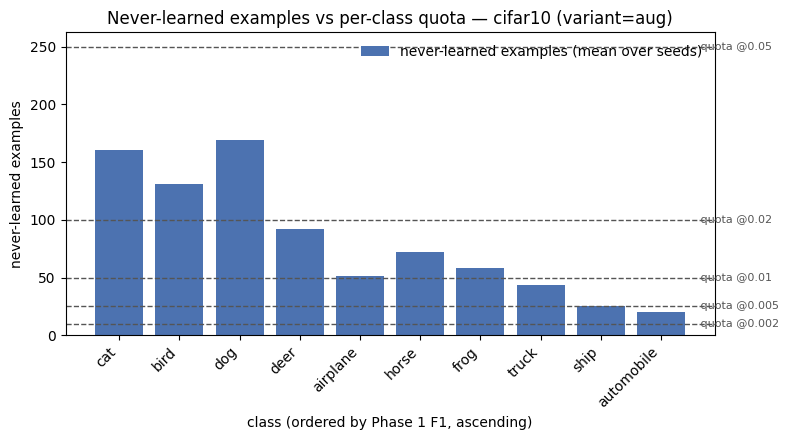

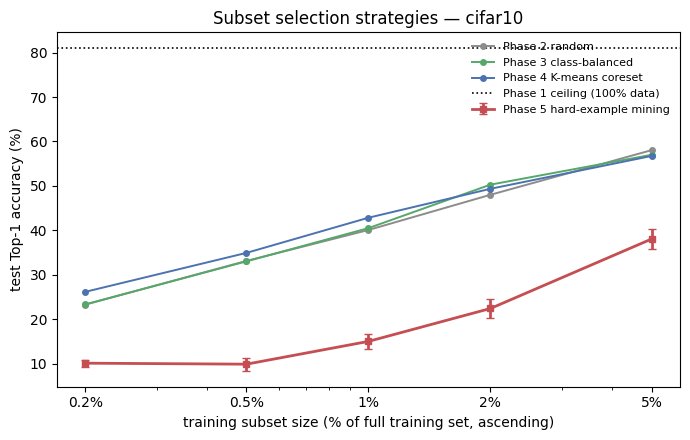

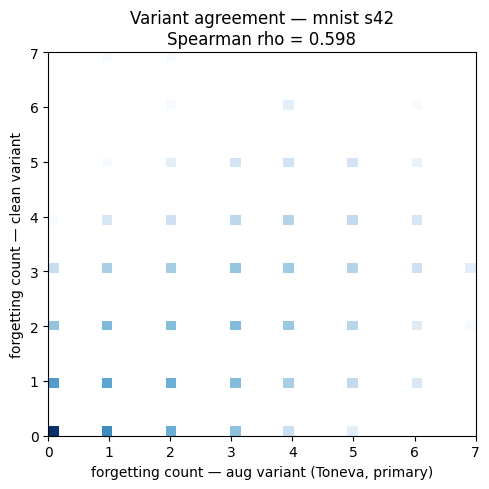

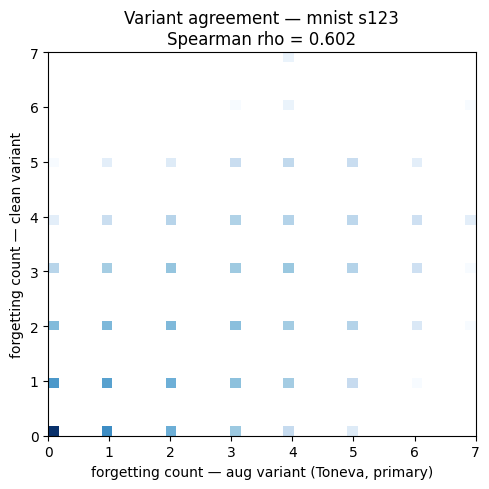

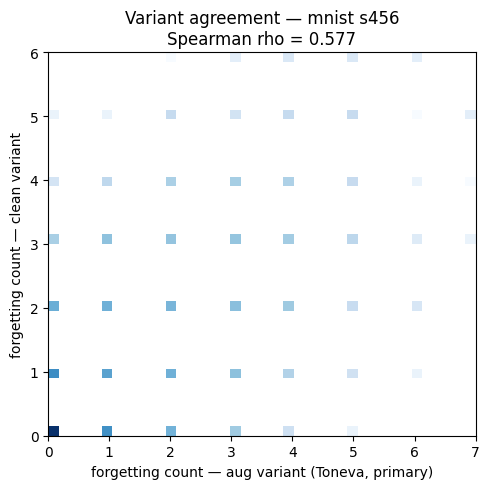

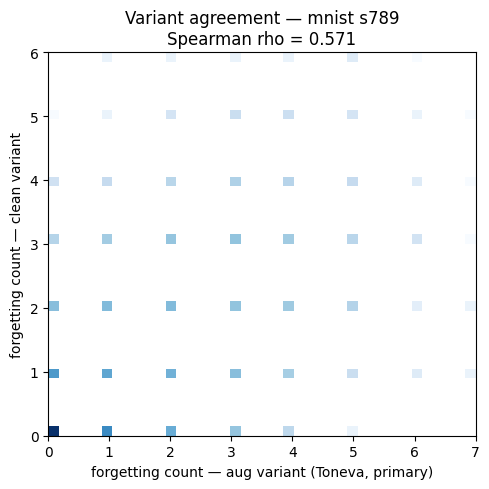

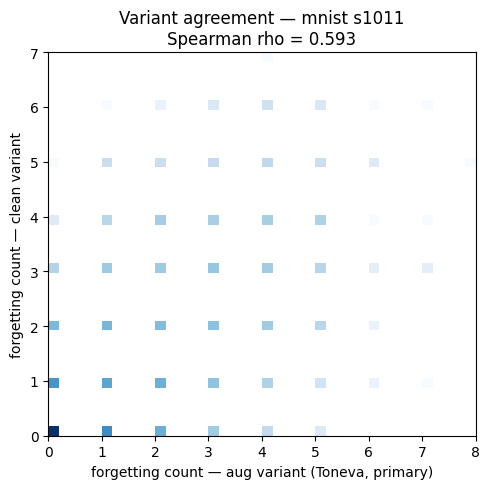

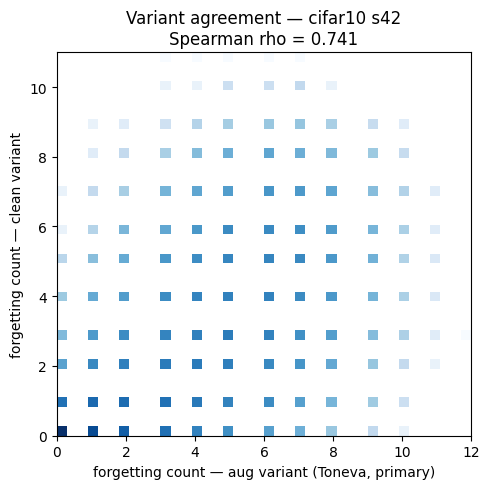

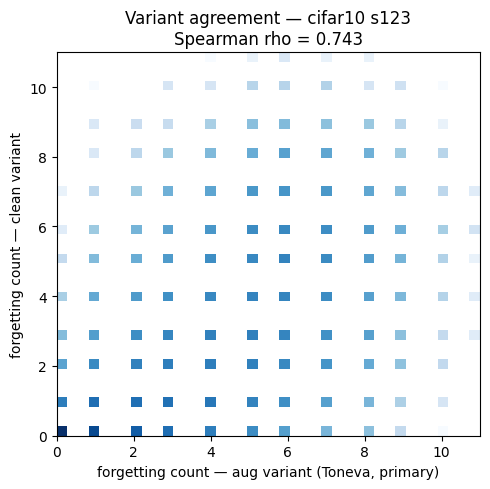

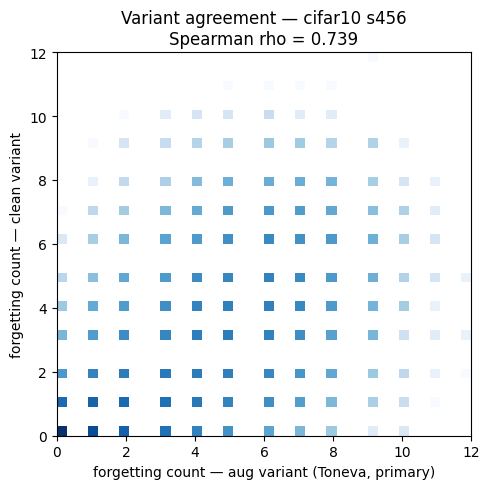

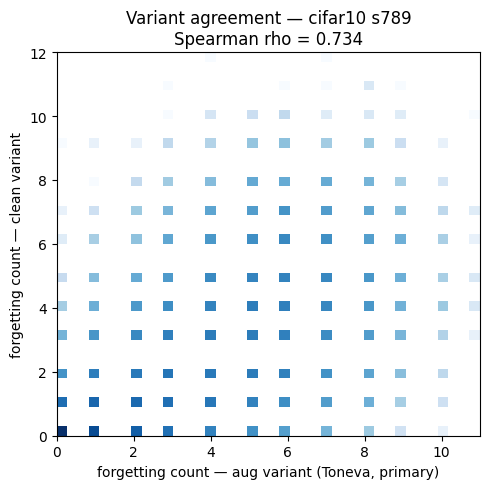

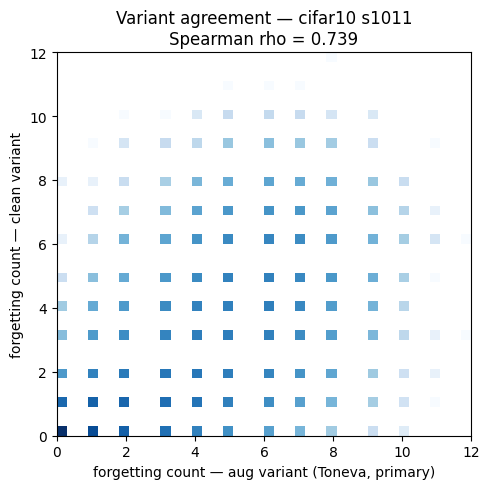

In [24]:
# ========== [CELL 13] Figures and persistence ==========
for ds in ("mnist", "cifar10"):
    fig_forgetting_histogram(ds, SEEDS[0], "aug")
    fig_never_learned_by_class(ds, diag_rows, "aug")
    fig_accuracy_vs_fraction(agg_rows, ds)

variant_agreement = {}
for ds in ("mnist", "cifar10"):
    for s in SEEDS:
        _, rho, p = fig_variant_agreement(ds, s)
        variant_agreement[f"{ds}_s{s}"] = dict(spearman=rho, p=p)

save_all(results, agg_rows, sel_reports, diag_rows, extra=dict(variant_agreement=variant_agreement))


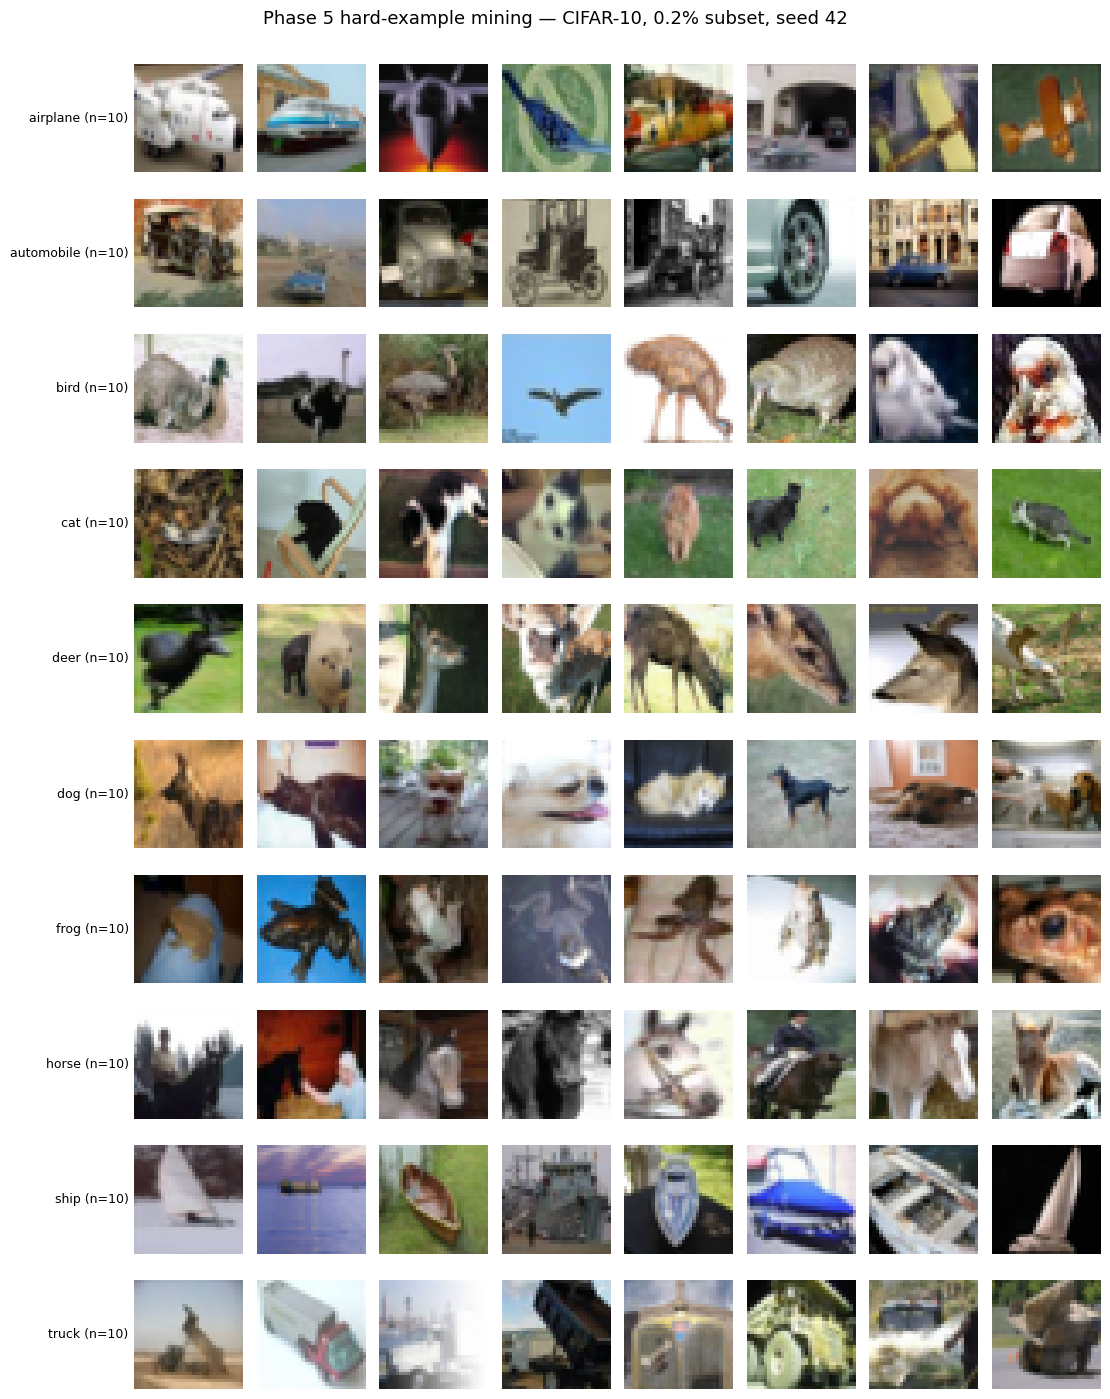

Saved: /kaggle/working/phase5/fig_selection_grid_cifar10_0.002.png


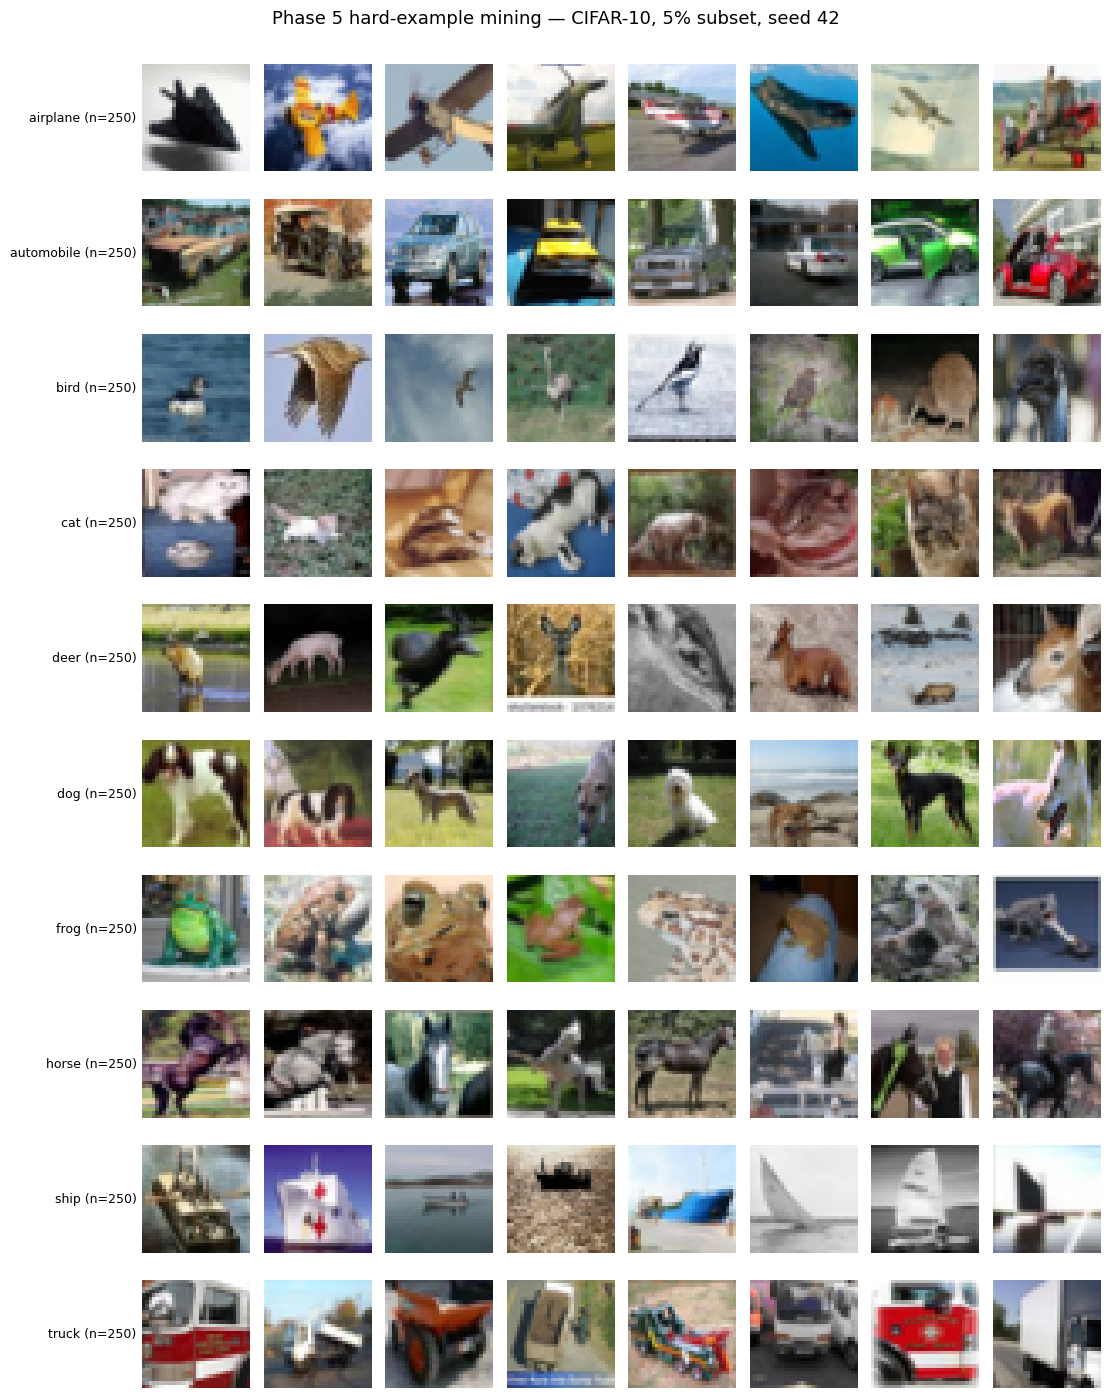

Saved: /kaggle/working/phase5/fig_selection_grid_cifar10_0.05.png


In [22]:
# ========== [CELL 14] Selection grid — requires the Phase 3 utility pasted into the cell above this one ==========
# plot_selection_grid(dataset_name, indices, class_names, title, save_path, n_per_class) was built in
# Phase 3, is transform-free and validated on real data. Reuse unchanged; do not rebuild.

_train_full = build_dataset("cifar10", train=True, augment=True)
for _f in (0.002, 0.05):
    _idx = sample_indices(_train_full, _f, SEEDS[0])
    plot_selection_grid(
        "cifar10", _idx, CLASS_NAMES["cifar10"],
        f"Phase 5 hard-example mining — CIFAR-10, {_f*100:g}% subset, seed {SEEDS[0]}",
        os.path.join(OUT_DIR, f"fig_selection_grid_cifar10_{_f}.png"),
        n_per_class=8,
    )
def get_raw_dataset(dataset_name: str):
    """
    Transform-free training set — ToTensor only, no normalise,
    no augmentation. Used ONLY for display, never for training.
    """
    root = '/kaggle/working/data'
    raw_transform = transforms.Compose([transforms.ToTensor()])
    if dataset_name == 'MNIST':
        return torchvision.datasets.MNIST(
            root, train=True, download=True, transform=raw_transform)
    else:
        return torchvision.datasets.CIFAR10(
            root, train=True, download=True, transform=raw_transform)


def plot_selection_grid(dataset_name, indices, class_names, title,
                         save_path, n_per_class=5):
    """
    Render one row per class, up to `n_per_class` example images
    per row, labelled '<class> (n=<realised count>)'.

    The realised count is the point of the figure: a random
    selection (Phase 2) shows uneven n per row; a class-balanced
    selection (Phase 3) shows constant n per row. That contrast
    IS the visual evidence for the Phase 2 vs Phase 3 comparison.

    dataset_name: 'MNIST' or 'CIFAR10' — used to load the raw
        (transform-free) dataset for display, independent of
        whatever transform was used for training.
    indices: the exact index list returned by sample_indices().
    class_names: e.g. [str(i) for i in range(10)] for MNIST, or
        CIFAR_CLASSES for CIFAR10.
    """
    raw_ds = get_raw_dataset(dataset_name)
    labels = np.asarray(raw_ds.targets)
    indices = np.asarray(indices)
    num_classes = len(class_names)

    fig, axes = plt.subplots(
        num_classes, n_per_class,
        figsize=(n_per_class * 1.4, num_classes * 1.4)
    )

    for row, cls in enumerate(range(num_classes)):
        cls_selected = indices[labels[indices] == cls]
        realised_n = len(cls_selected)

        for col in range(n_per_class):
            ax = axes[row, col]
            ax.axis('off')
            if col < realised_n:
                img_idx = cls_selected[col]
                img, _ = raw_ds[img_idx]
                img = img.permute(1, 2, 0).numpy()
                if img.shape[2] == 1:
                    ax.imshow(img.squeeze(), cmap='gray')
                else:
                    ax.imshow(img)

        axes[row, 0].set_ylabel(
            f'{class_names[cls]} (n={realised_n})',
            rotation=0, ha='right', va='center', fontsize=9
        )
        axes[row, 0].axis('on')
        axes[row, 0].set_xticks([])
        axes[row, 0].set_yticks([])
        for spine in axes[row, 0].spines.values():
            spine.set_visible(False)

    fig.suptitle(title, fontsize=13, y=1.0)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')

In [23]:
import os
bad = os.path.join(OUT_DIR, "forgetting_mnist_seed42_8a0370e660.npz")
if os.path.exists(bad):
    os.remove(bad)
    print("removed", bad)
else:
    print("already gone")

# confirm what survives
import glob
for p in sorted(glob.glob(os.path.join(OUT_DIR, "forgetting_*.npz"))):
    print("  keep:", os.path.basename(p))

removed /kaggle/working/phase5/forgetting_mnist_seed42_8a0370e660.npz
  keep: forgetting_cifar10_seed1011_8a0370e660.npz
  keep: forgetting_cifar10_seed123_8a0370e660.npz
  keep: forgetting_cifar10_seed42_8a0370e660.npz
  keep: forgetting_cifar10_seed456_8a0370e660.npz
  keep: forgetting_cifar10_seed789_8a0370e660.npz
  keep: forgetting_mnist_seed1011_8a0370e660.npz
  keep: forgetting_mnist_seed123_8a0370e660.npz
  keep: forgetting_mnist_seed456_8a0370e660.npz
  keep: forgetting_mnist_seed789_8a0370e660.npz
